In [1]:
import os
import sys
from ipywidgets import interact

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_notebook import *

%matplotlib widget

In [2]:
project_name = "syn"
condition = "debug"
data = "test1"
switch_epoch = 10000

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])
data_module = get_data_module(project_name,  experiment_name)

data_module.setup()

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt


In [3]:
def get_centroid(mask):
    """
    Calcule le centre de masse avec :
    - x, y normalisés entre -1 et 1
    - (1, 1) correspondant au coin HAUT-DROITE
    """
    B, _, H, W = mask.shape
    device = mask.device
    
    # 1. Création des grilles de -1 à 1
    # Pour x : de gauche (-1) à droite (1)
    # Pour y : de bas (-1) à haut (1) -> on inverse l'ordre de linspace
    grid_x = torch.linspace(-1, 1, W, device=device)
    grid_y = torch.linspace(1, -1, H, device=device) # Inversion ici : le haut est 1
    
    mesh_y, mesh_x = torch.meshgrid(grid_y, grid_x, indexing='ij')
    
    # 2. Calcul de la masse totale
    total_mass = mask.sum(dim=(2, 3)) + 1e-8
    
    # 3. Pondération par les intensités du masque
    # (B, 1, H, W) * (H, W) -> Somme sur H, W -> (B, 1)
    pos_x = (mask * mesh_x).sum(dim=(2, 3)) / total_mass
    pos_y = (mask * mesh_y).sum(dim=(2, 3)) / total_mass
    
    # 4. Retourne (B, 2)
    return torch.cat([pos_x, pos_y], dim=1)

def get_mask(images, temperature=20.0):
    # On binarise fort pour éviter le flou central
    grayscale = images.mean(dim=1, keepdim=True)
    return torch.sigmoid((grayscale - 0.1) * temperature)


def get_area(tensor):
    area = tensor.sum(dim=(1, 2, 3))
    area_norm = (area - 25) / (128 - 25 + 1e-8)
    return torch.clamp(area_norm, 0.0, 1.0)

def dice_loss(pred, target, smooth=0.1):
    """
    Computes the Dice Loss for binary segmentation.
    Args:
        pred: Tensor of predictions (batch_size, 1, H, W).
        target: Tensor of ground truth (batch_size, 1, H, W).
        smooth: Smoothing factor to avoid division by zero.
    Returns:
        Scalar Dice Loss.
    """
    # Apply sigmoid to convert logits to probabilities
    
    # Calculate intersection and union
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    
    # Compute Dice Coefficient
    dice = (2. * intersection + smooth) / (union + smooth)
    
    # Return Dice Loss
    return 1 - dice.mean()


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

class SimpleMapper(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 12),
        )

    def forward(self, x):
        return self.net(x)

def train(visual_module, dataloader, num_epochs=20):
    device = next(visual_module.parameters()).device
    visual_module.eval()

    mapper = SimpleMapper().to(device)
    optimizer = optim.Adam(mapper.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        mapper.train()
        total_loss = 0.0

        for batch in dataloader:
            images_raw = batch[0][frozenset({'attr', 'v_latents'})]['v_latents'].to(device)
            attr_dict = batch[0][frozenset({'attr', 'v_latents'})]['attr']
            attr_combined = torch.cat([attr_dict[0].to(device), attr_dict[1].to(device)], dim=1)

            with torch.no_grad():
                x_target = visual_module.decode_images(images_raw)
                mask_target = get_mask(x_target)
                target_area = get_area(mask_target).float().to(device)
                target_centroid = get_centroid(mask_target)

            pred = mapper(attr_combined)
            x_pred = visual_module.decode_images(pred)
            mask_pred = get_mask(x_pred)
            pred_area = get_area(mask_pred).float().to(device)
            pred_centroid = get_centroid(mask_pred)

            print(f"pred area {pred_area.sum()}")

            target_loss = F.mse_loss(pred_area, target_area)
            centroid_loss = F.mse_loss(pred_centroid, target_centroid)
            d_loss = dice_loss(mask_pred, mask_target)

            optimizer.zero_grad()
            loss =  d_loss
            loss.backward()

            for name, p in mapper.named_parameters():
                    print(name, p.grad.abs().mean().item())
                    optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch} | loss={total_loss / len(dataloader):.6f}")

    return mapper

In [5]:
# --- 4. VISUALISATION ---
def visualize_results(mapper, visual_module):
    mapper.eval()
    device = next(mapper.parameters()).device
    
    # Simulation de 5 scénarios (x, y, size, rot)
    # On va tester une CATEGORIE fixe (ex: la première) pour voir le mouvement
    scenarios = [
        # x,   y,  size, rot
        [0.5, 0.5, 0.5, 0.0],  # Centre
        [0.1, 0.1, 0.3, 0.0],  # Bas-Gauche, petit
        [0.9, 0.9, 0.8, 0.25], # Haut-Droite, gros, rot 90°
        [0.1, 0.9, 0.5, 0.5],  # Haut-Gauche, rot 180°
        [0.9, 0.1, 0.5, 0.75], # Bas-Droite, rot 270°
    ]
    
    all_inputs = []
    for s in scenarios:
        x, y, size, rot = s
        # 1. Catégorie One-hot (Taille 3) - on fixe la catégorie 0
        cat = torch.tensor([1, 0, 0]).float() 
        
        # 2. Attributs normalisés (Taille 5)
        rot_rad = rot * 2 * math.pi
        attr = torch.tensor([
            x * 2 - 1, 
            y * 2 - 1, 
            size * 2 - 1, 
            math.cos(rot_rad), 
            math.sin(rot_rad)
        ]).float()
        
        # 3. Concaténation (Taille 8)
        full_input = torch.cat([cat, attr])
        all_inputs.append(full_input)
    
    input_tensor = torch.stack(all_inputs).to(device)
    
    with torch.no_grad():
        # Maintenant le mapper et les coords sont sur le même device
        z = mapper(input_tensor)
        imgs = visual_module.decode_images(z)
    
    # ... reste du code (matplotlib gère le passage en CPU automatiquement avec .cpu())
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i in range(3):
        # On n'oublie pas le .cpu() pour l'affichage avec matplotlib
        axes[i].imshow(imgs[i].mean(0).detach().cpu().numpy(), cmap='gray')
        axes[i].set_title(f"Target")
    plt.show()

In [6]:
mapper = train(visual_module, data_module.train_dataloader(), 300)

pred area 30.234498977661133
net.0.weight 3.1817994567973074e-06
net.0.bias 8.639062798465602e-06
net.2.weight 4.477344191400334e-06
net.2.bias 2.6069608793477528e-05
net.4.weight 1.9272014469606802e-05
net.4.bias 0.0002828589058481157
Epoch 0 | loss=0.859771
pred area 32.0
net.0.weight 0.00012676030746661127
net.0.bias 0.00036104052560403943
net.2.weight 0.0001218157121911645
net.2.bias 0.0006483901524916291
net.4.weight 0.0010622050613164902
net.4.bias 0.007109060883522034
Epoch 1 | loss=0.786190
pred area 32.0
net.0.weight 0.00010725053289206699
net.0.bias 0.00023653608513996005
net.2.weight 9.672334999777377e-05
net.2.bias 0.0004708567284978926
net.4.weight 0.0009257874917238951
net.4.bias 0.00395612046122551
Epoch 2 | loss=0.737540
pred area 32.0
net.0.weight 9.972171392291784e-05
net.0.bias 0.00015032108058221638
net.2.weight 6.198369374033064e-05
net.2.bias 0.00025826829369179904
net.4.weight 0.0007552056340500712
net.4.bias 0.002807309851050377
Epoch 3 | loss=0.704735
pred area

In [7]:
mapper.eval()

samples = data_module.get_samples('train', 10)
attr_dict = samples[frozenset({'attr', 'v_latents'})]['attr']
attr_combined = torch.cat([attr_dict[0].to(device), attr_dict[1].to(device)], dim=1)

v_latent_pred = mapper.forward(attr_combined)
v_latent_target = samples[frozenset({'attr', 'v_latents'})]['v_latents']


In [8]:
images_target = visual_module.decode_images(v_latent_target.to(device))
images_pred= visual_module.decode_images(v_latent_pred)

In [9]:
images_target_np = images_target.permute(0, 2, 3, 1).detach().cpu().numpy()
images_pred_np = images_pred.permute(0, 2, 3, 1).detach().cpu().numpy()

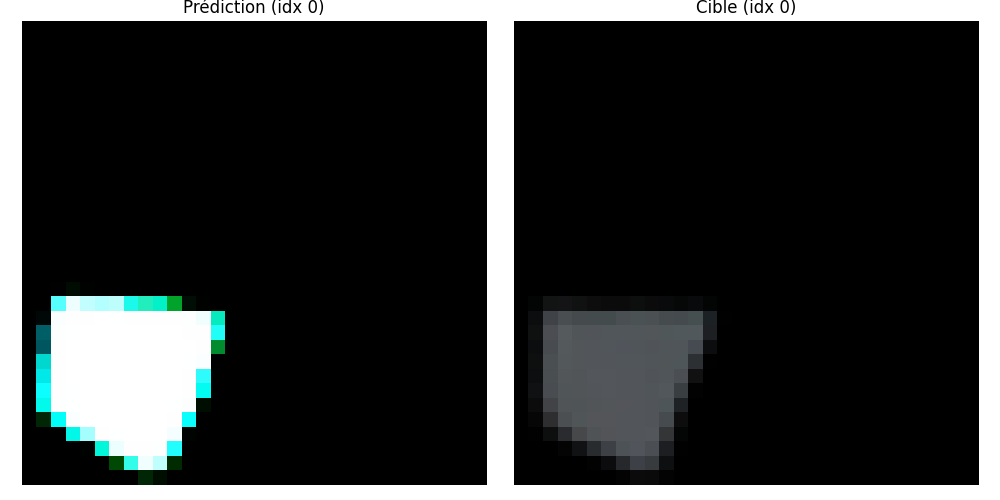

In [10]:
import matplotlib.pyplot as plt

idx = 0

# Création d'une figure avec 1 ligne et 2 colonnes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Affichage de la prédiction
axes[0].imshow(images_pred_np[idx])
axes[0].set_title(f"Prédiction (idx {idx})")
axes[0].axis('off') # Optionnel : enlève les axes gradués

# Affichage de la cible
axes[1].imshow(images_target_np[idx])
axes[1].set_title(f"Cible (idx {idx})")
axes[1].axis('off')

plt.tight_layout() # Ajuste l'espacement entre les images
plt.show()

In [11]:
global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
test_samples = get_data_samples(data_module, 32, split= "train")

x_target = visual_module.decode_images(test_samples[frozenset(["v_latents", "attr"])]["v_latents"]).detach().cpu()


mask_target = get_mask(x_target)



Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt


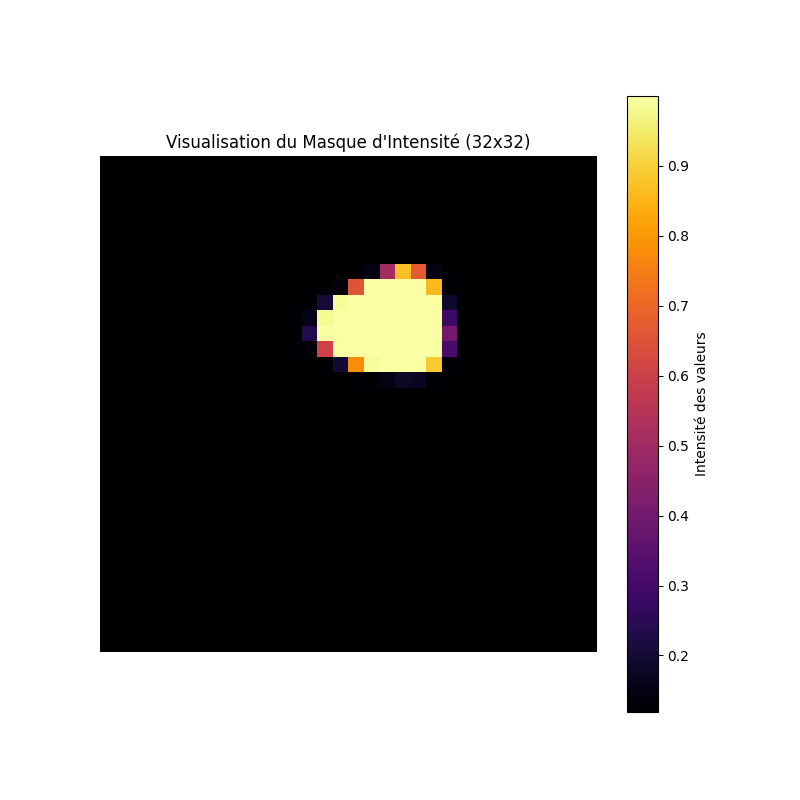

In [12]:
import matplotlib.pyplot as plt
import torch

# Supposons que ton tenseur s'appelle mask_tensor
mask_tensor = mask_target # Remplace par ton vrai tenseur

# 1. Préparation du tenseur pour Matplotlib
# Ton tenseur a une forme (1, 32, 32) -> il faut enlever la dimension inutile de 1.
# On le passe aussi sur CPU et on le convertit en tableau NumPy.
mask_np = mask_tensor.squeeze().cpu().numpy()

# 2. Visualisation
plt.figure(figsize=(8, 8)) # Définit la taille de la figure

# imshow affiche une image d'intensité.
# cmap='viridis' (par défaut) est excellent, 'inferno' ou 'magma' sont aussi bien pour l'intensité.
img = plt.imshow(mask_np[3], cmap='inferno') 

# Ajout d'une barre de couleur pour comprendre l'échelle (qui sera très faible !)
plt.colorbar(img, label='Intensité des valeurs')

plt.title("Visualisation du Masque d'Intensité (32x32)")
plt.axis('off') # Cache les coordonnées X et Y pour un rendu plus propre

plt.show()